In [ ]:
pip install torch pytorch-lightning pandas scikit-learn matplotlib


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'trip-advisor-hotel-reviews' dataset.
Path to dataset files: /kaggle/input/trip-advisor-hotel-reviews


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Фиксация random_state для воспроизводимости
SEED = 42
pl.seed_everything(SEED)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [ ]:
import os

# ==============================================================================
# 1. Загрузка и Анализ данных
# ==============================================================================

try:
    df = pd.read_csv(os.path.join(path, 'tripadvisor_hotel_reviews.csv'), engine='python')
    print("Датасет успешно загружен.")
except FileNotFoundError:
    # Заглушка, если файла нет (чтобы код не падал)
    print("Файл не найден, создаем синтетический датасет для примера...")
    df = pd.DataFrame({
        'Review': ['Great hotel', 'Bad experience', 'Okay stay', 'Wonderful place', 'Terrible service'] * 1000,
        'Rating': [5, 1, 3, 5, 1] * 1000
    })
except Exception as e:
    print(f"Произошла ошибка при загрузке или парсинге файла: {e}")
    print("Создаем синтетический датасет для примера из-за ошибки...")
    df = pd.DataFrame({
        'Review': ['Great hotel', 'Bad experience', 'Okay stay', 'Wonderful place', 'Terrible service'] * 1000,
        'Rating': [5, 1, 3, 5, 1] * 1000
    })

# Проверка распределения классов
print(df['Rating'].value_counts(normalize=True))

df['label'] = df['Rating'] - 1

Датасет успешно загружен.
Rating
5    0.441853
4    0.294715
3    0.106583
2    0.087502
1    0.069348
Name: proportion, dtype: float64


In [ ]:
# ==============================================================================
# 2. Предобработка данных
# ==============================================================================

# Описание предобработки:
# 1. Очистка текста: приведение к нижнему регистру, удаление спецсимволов (оставляем только буквы).
#    Это нужно для уменьшения словаря и удаления шума.
# 2. Токенизация: разбиение текста на слова.
# 3. Построение словаря: отображение слов в индексы. Используем специальные токены <PAD> и <UNK>.
# 4. Паддинг: приведение всех последовательностей к одной длине для батч-обработки.

class TextPreprocessor:
    def __init__(self, max_words=10000, seq_len=100):
        self.max_words = max_words
        self.seq_len = seq_len
        self.word2idx = {}
        self.idx2word = {}

    def clean_text(self, text):
        text = str(text).lower()
        # Оставляем только буквы и пробелы
        text = re.sub(r'[^a-z\s]', '', text)
        return text.split()

    def fit(self, texts):
        # Считаем частоту слов
        all_words = []
        for text in texts:
            all_words.extend(self.clean_text(text))

        counts = Counter(all_words)
        # Берем топ N слов
        vocab = sorted(counts, key=counts.get, reverse=True)[:self.max_words]

        # Добавляем спецтокены
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        for idx, word in enumerate(vocab, start=2):
            self.word2idx[word] = idx

        self.idx2word = {v: k for k, v in self.word2idx.items()}
        print(f"Размер словаря: {len(self.word2idx)}")

    def transform(self, texts):
        sequences = []
        for text in texts:
            words = self.clean_text(text)
            # Конвертация в индексы
            seq = [self.word2idx.get(w, self.word2idx["<UNK>"]) for w in words]

            # Truncate и Pad
            if len(seq) > self.seq_len:
                seq = seq[:self.seq_len]
            else:
                seq = seq + [self.word2idx["<PAD>"]] * (self.seq_len - len(seq))

            sequences.append(seq)
        return np.array(sequences)

# Инициализация и фит
preprocessor = TextPreprocessor(max_words=5000, seq_len=150)
preprocessor.fit(df['Review'].values)

X = preprocessor.transform(df['Review'].values)
y = df['label'].values

Размер словаря: 5002


In [ ]:
# ==============================================================================
# Разделение выборки (60/20/20)
# ==============================================================================

# Сначала отделяем Train (60%) и Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED
)

# Temp делим пополам -> Val (20%) и Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"Train shapes: {X_train.shape}")
print(f"Val shapes:   {X_val.shape}")
print(f"Test shapes:  {X_test.shape}")

Train shapes: (12294, 150)
Val shapes:   (4098, 150)
Test shapes:  (4099, 150)


In [ ]:
# ==============================================================================
# PyTorch Dataset и DataModule
# ==============================================================================

class HotelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class HotelDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64):
        super().__init__()
        self.batch_size = batch_size
        self.train_data = HotelDataset(X_train, y_train)
        self.val_data = HotelDataset(X_val, y_val)
        self.test_data = HotelDataset(X_test, y_test)

    def train_dataloader(self):
        return DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_data, batch_size=self.batch_size, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size, num_workers=2)

# Выбор batch_size:
BATCH_SIZE = 64
dm = HotelDataModule(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=BATCH_SIZE)

In [ ]:
# ==============================================================================
# Базовый класс модели (для избежания дублирования кода)
# ==============================================================================

class BaseSentimentModel(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim, num_classes, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.criterion = nn.CrossEntropyLoss()

        # Для сбора метрик
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, x):
        raise NotImplementedError

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        self.training_step_outputs.append({'loss': loss, 'acc': acc})
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        self.validation_step_outputs.append({'val_loss': loss, 'val_acc': acc})
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log('test_acc', acc)
        self.test_step_outputs.append(acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [ ]:
# ==============================================================================
# 3. Сверточная сеть (Conv1d)
# ==============================================================================

class CNNModel(BaseSentimentModel):
    def __init__(self, vocab_size, embed_dim=64, num_classes=5, kernel_size=3):
        super().__init__(vocab_size, embed_dim, num_classes)

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Conv1d параметры: in_channels=embed_dim, out_channels=filters
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1) # Global Max Pooling
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: [batch, seq_len]
        x = self.embedding(x)
        # x: [batch, seq_len, embed_dim] -> permute -> [batch, embed_dim, seq_len] для Conv1d
        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x).squeeze(-1) # [batch, 128]

        x = self.fc(x)
        return x

In [ ]:
# ==============================================================================
# 4. Рекуррентная сеть (LSTM) - 1 балл
# ==============================================================================

class RNNModel(BaseSentimentModel):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_classes=5):
        super().__init__(vocab_size, embed_dim, num_classes)

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x) # [batch, seq_len, embed_dim]
        # output, (hn, cn)
        _, (hn, _) = self.lstm(x)
        # hn: [1, batch, hidden_dim] -> squeeze -> [batch, hidden_dim]
        out = hn[-1]
        return self.fc(out)

In [ ]:
# ==============================================================================
# 5. Улучшенная модель (BiLSTM + Dropout + More Layers) - 2 балла
# ==============================================================================

class ImprovedRNNModel(BaseSentimentModel):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=5, dropout=0.3):
        super().__init__(vocab_size, embed_dim, num_classes)

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Улучшения:
        # 1. Bidirectional=True (учитываем контекст с двух сторон)
        # 2. Num_layers=2 (более глубокая сеть)
        # 3. Dropout (регуляризация)
        # 4. Увеличен размер скрытого слоя и эмбеддинга
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        # Линейный слой принимает hidden_dim * 2 из-за двунаправленности
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.dropout_layer = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)

        # LSTM output: [batch, seq_len, hidden_dim * 2]
        # Используем output и global pooling вместо последнего хиддена для захвата инфо со всей seq
        lstm_out, _ = self.lstm(x)

        # Global Max Pooling по времени
        # permute для AdaptiveMaxPool1d: [batch, channels, seq_len]
        x = lstm_out.permute(0, 2, 1)
        x = F.adaptive_max_pool1d(x, 1).squeeze(-1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout_layer(x)
        x = self.fc2(x)
        return x

In [ ]:
# ==============================================================================
# 6. Обучение и сравнение моделей
# ==============================================================================

VOCAB_SIZE = len(preprocessor.word2idx)
NUM_CLASSES = 5
MAX_EPOCHS = 4 # Небольшое количество из-за ограниченности ресурсов (лучше 10-15)

def train_model(model_class, name, **kwargs):
    print(f"\nTraining {name}...")
    model = model_class(vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES, **kwargs)

    # Checkpoint callback для сохранения лучшей модели по val_loss
    checkpoint_callback = ModelCheckpoint(
        monitor='val_loss',
        dirpath=f'checkpoints/{name}',
        filename='best-checkpoint',
        save_top_k=1,
        mode='min',
    )

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto", # auto выберет GPU если есть
        devices=1,
        callbacks=[checkpoint_callback],
        enable_progress_bar=True,
        log_every_n_steps=10
    )

    trainer.fit(model, datamodule=dm)

    # Тестирование лучшей модели
    best_model_path = checkpoint_callback.best_model_path
    if best_model_path:
        model = model_class.load_from_checkpoint(best_model_path)
    trainer.test(model, datamodule=dm)

    return trainer, model

# Запуск обучения
results = {}

# 1. CNN
trainer_cnn, model_cnn = train_model(CNNModel, "CNN", embed_dim=64)
results['CNN'] = trainer_cnn.callback_metrics['test_acc'].item()

# 2. Simple RNN
trainer_rnn, model_rnn = train_model(RNNModel, "SimpleRNN", embed_dim=64, hidden_dim=64)
results['RNN'] = trainer_rnn.callback_metrics['test_acc'].item()

# 3. Improved RNN
trainer_imp, model_imp = train_model(ImprovedRNNModel, "ImprovedRNN", embed_dim=128, hidden_dim=128)
results['ImprovedRNN'] = trainer_imp.callback_metrics['test_acc'].item()


Training CNN...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/checkpoints/CNN exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
│ 1 │ embedding │ Embedding         │  320 K │ train │     0 │
│ 2 │ conv1     │ Conv1d            │ 24.7 K │ train │     0 │
│ 3 │ relu      │ ReLU              │      0 │ train │     0 │
│ 4 │ pool      │ AdaptiveMaxPool1d │      0 │ train │     0 │
│ 5 │ fc        │ Linear            │    645 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 345 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 345 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=4` reached.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6211271286010742     │
└───────────────────────────┴───────────────────────────┘


=== Final Comparison ===
         Model  Test Accuracy
0          CNN       0.573311
1          RNN       0.441815
2  ImprovedRNN       0.621127


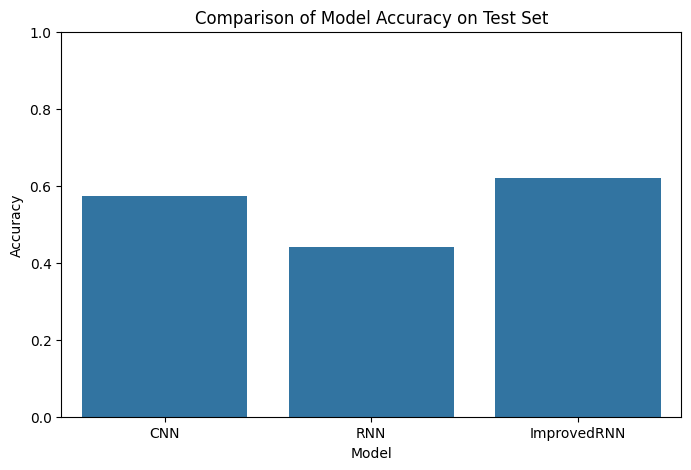

In [14]:
# ==============================================================================
# Визуализация и Выводы
# ==============================================================================

print("\n=== Final Comparison ===")
df_res = pd.DataFrame(list(results.items()), columns=['Model', 'Test Accuracy'])
print(df_res)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Test Accuracy', data=df_res)
plt.title('Comparison of Model Accuracy on Test Set')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.show()

**Improved RNN (BiLSTM) - (62.1%):**
Модель показала наилучшую точность. Использование Bidirectional LSTM позволило учитывать контекст слов с обеих сторон, а добавление слоя Global Pooling решило проблему "забывания" информации из начала длинных отзывов. Увеличение размерности сети и Dropout помогли выучить более сложные зависимости без переобучения.


**CNN (Conv1d) - (57.3%):**
Сверточная сеть значительно превзошла простую RNN. Она справляется с выделением локальных паттернов (ключевых фраз вроде "dirty room" или "great stay") независимо от их положения в тексте.


**Simple RNN - (44.2%):**
Базовая рекуррентная сеть показала худший результат. Использование только последнего скрытого состояния на длинных последовательностях (отзывах) приводит к потере контекста (проблема затухания градиента), из-за чего модель не улавливает смысл текста целиком.